*Copyright (c) 2026 Mapenzi Supaki*

Shield: [![CC BY-NC 4.0][cc-by-nc-shield]][cc-by-nc]

This work is licensed under a
[Creative Commons Attribution-NonCommercial 4.0 International License][cc-by-nc].

[![CC BY-NC 4.0][cc-by-nc-image]][cc-by-nc]

[cc-by-nc]: https://creativecommons.org/licenses/by-nc/4.0/
[cc-by-nc-image]: https://licensebuttons.net/l/by-nc/4.0/88x31.png
[cc-by-nc-shield]: https://img.shields.io/badge/License-CC%20BY--NC%204.0-lightgrey.svg

## **Stage 1: Setup**

**Import libraries and set display options**

In [1]:
# import data analysis libraries
import pandas as pd
import numpy as np

# plotting libraries for later EDA
import matplotlib.pyplot as plt
import seaborn as sns

# make notebook output easier to read
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

import io
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

## **Stage 2: Data Loading & Initial Inspection**

Load all datasets from provided CSV strings. Each dataset serves a specific purpose in the analysis:
- fintech_users: User demographic and acquisition information
- fintech_devices: Device characteristics for technical friction analysis
- network_logs: Network conditions during onboarding
- sessions: Session timing and duration context
- kyc_events: Core funnel events with status and error codes

In [2]:
# load all source files
users = pd.read_csv('fintech_users.csv')
devices = pd.read_csv('fintech_devices.csv')
network = pd.read_csv('network_logs.csv')
sessions = pd.read_csv('sessions.csv')
kyc_events = pd.read_csv('kyc_events.csv')

In [3]:
# Show columns and first few rows for each table
for name, df in {
    "users": users,
    "devices": devices,
    "network": network,
    "sessions": sessions,
    "events": kyc_events
}.items():
    print(f"\n=== {name.upper()} ===")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print(df.head(3))


=== USERS ===
Shape: (100000, 6)
Columns: ['user_id', 'signup_time', 'age', 'country', 'acquisition_source', 'fraud_risk_score']
    user_id                 signup_time  age       country acquisition_source  fraud_risk_score
0  U0000000  2025-12-24 00:52:47.417800   56       Nigeria         google_ads          0.105444
1  U0000001  2026-02-04 09:33:22.690565   46  South Africa       facebook_ads          0.340049
2  U0000002  2026-02-20 11:11:19.681056   32            UK         google_ads          0.484566

=== DEVICES ===
Shape: (100000, 5)
Columns: ['user_id', 'device_type', 'os', 'device_model', 'camera_quality_score']
    user_id device_type       os  device_model  camera_quality_score
0  U0000000      mobile  Android     iPhone 13                     6
1  U0000001      mobile  Android  Infinix Note                     4
2  U0000002      mobile  Android   Tecno Spark                     3

=== NETWORK ===
Shape: (100000, 5)
Columns: ['user_id', 'network_type', 'latency_ms', 'pack

## **Stage 3: Data Audit & Quality Checks**

Comprehensive data audit to understand dataset structure, quality, and relationships.
This is crucial for identifying potential issues before analysis.

In [4]:
def audit_table(df, name):
    print(f"\n--- AUDIT: {name} ---")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

    print("Data Types:\n", df.dtypes)

    print("\nMissing values:\n", df.isna().sum())

    print("\nDuplicates:", df.duplicated().any())

    print("\nUnique values (for object columns):")
    for col in df.columns:
        if df[col].dtype == 'object':
            print(f"  {col}: {df[col].nunique()} unique values")

    # For numeric cols
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    if len(num_cols) > 0:
        print("\nNumeric Summary:\n", df[num_cols].describe())



# Run audit on each table
audit_table(users, "users")
audit_table(devices, "devices")
audit_table(network, "network")
audit_table(sessions, "sessions")
audit_table(kyc_events, "events")


--- AUDIT: users ---
Rows: 100000, Columns: 6
Memory usage: 25458.38 KB
Data Types:
 user_id                object
signup_time            object
age                     int64
country                object
acquisition_source     object
fraud_risk_score      float64
dtype: object

Missing values:
 user_id               0
signup_time           0
age                   0
country               0
acquisition_source    0
fraud_risk_score      0
dtype: int64

Duplicates: False

Unique values (for object columns):
  user_id: 100000 unique values
  signup_time: 100000 unique values
  country: 5 unique values
  acquisition_source: 6 unique values

Numeric Summary:
                  age  fraud_risk_score
count  100000.000000     100000.000000
mean       41.022480          0.199716
std        13.526548          0.120542
min        18.000000          0.000352
25%        29.000000          0.107104
50%        41.000000          0.179457
75%        53.000000          0.271902
max        64.000000     

Overall, the data is very clean. The audit_table function successfully ran for all five dataframes (users, devices, network, sessions, and kyc_events), providing a detailed overview of each dataset's structure and quality:

- For each table, it shows the number of rows and columns, along with its memory usage.
- It lists the data type for each column, which is essential for understanding how the data is stored.
- It identifies any missing values, column by column. The only column with missing values is error_code in the kyc_events table, which is expected as errors don't occur in all events.
- It confirms that there are no duplicate rows across any of the tables.
- For object-type columns, it shows the count of unique values, which helps in identifying categorical data and potential inconsistencies.
- For numerical columns, it provides descriptive statistics such as count, mean, standard deviation, and quartile ranges, giving insights into the data distribution.

In [5]:
# Cross-table consistency checks
# sets of unique user_id values from the dataframes
users_list = set(users['user_id'].unique())
devices_list = set(devices['user_id'].unique())
sessions_list = set(sessions['user_id'].unique())
kyc_list = set(kyc_events['user_id'].unique())
network_list = set(network['user_id'].unique())

# print the total number of unique users found in each of the tables
print(f"\nUsers in users table: {len(users_list)}")
print(f"Users in devices table: {len(devices_list)}")
print(f"Users in sessions table: {len(sessions_list)}")
print(f"Users in kyc_events table: {len(kyc_list)}")
print(f"Users in network_logs table: {len(network_list)}")

# Check if all users in core tables are consistent
core_users = users_list & devices_list & sessions_list & kyc_list
print(f"\nUsers present in all core tables (users, devices, sessions, kyc_events): {len(core_users)}")
print(f"These are: {sorted(core_users)}")




Users in users table: 100000
Users in devices table: 100000
Users in sessions table: 100000
Users in kyc_events table: 100000
Users in network_logs table: 100000

Users present in all core tables (users, devices, sessions, kyc_events): 100000
These are: ['U0000000', 'U0000001', 'U0000002', 'U0000003', 'U0000004', 'U0000005', 'U0000006', 'U0000007', 'U0000008', 'U0000009', 'U0000010', 'U0000011', 'U0000012', 'U0000013', 'U0000014', 'U0000015', 'U0000016', 'U0000017', 'U0000018', 'U0000019', 'U0000020', 'U0000021', 'U0000022', 'U0000023', 'U0000024', 'U0000025', 'U0000026', 'U0000027', 'U0000028', 'U0000029', 'U0000030', 'U0000031', 'U0000032', 'U0000033', 'U0000034', 'U0000035', 'U0000036', 'U0000037', 'U0000038', 'U0000039', 'U0000040', 'U0000041', 'U0000042', 'U0000043', 'U0000044', 'U0000045', 'U0000046', 'U0000047', 'U0000048', 'U0000049', 'U0000050', 'U0000051', 'U0000052', 'U0000053', 'U0000054', 'U0000055', 'U0000056', 'U0000057', 'U0000058', 'U0000059', 'U0000060', 'U0000061', 

This cross-table consistency checks, shows how many users are present in all the 'core' tables. This ensures there is data integrity for analysis as it involves combined data sources. The check also prints the count of these consistent users and a sorts a list of their IDs.


In [6]:
# Check session_id consistency

sessions_from_kyc = set(kyc_events['session_id'].unique())
sessions_from_sessions = set(sessions['session_id'].unique())
print(f"\nUnique session_id in kyc_events: {len(sessions_from_kyc)}")
print(f"Unique session_id in sessions: {len(sessions_from_sessions)}")
print(f"All session_ids match: {sessions_from_kyc == sessions_from_sessions}")

# Check for orphaned records
users_without_kyc = users_list - kyc_list
print(f"\nUsers with no KYC events: {len(users_without_kyc)}")
if users_without_kyc:
    print(f"  These users exist but never started KYC: {users_without_kyc}")

# Check whether event user_ids all exist in users
missing_event_users = set(kyc_events["user_id"]) - set(users["user_id"])
print("\nUsers in events not found in users:", len(missing_event_users))

# Check whether event session_ids all exist in sessions
missing_event_sessions = set(kyc_events["session_id"]) - set(sessions["session_id"])
print("\nSessions in events not found in sessions:", len(missing_event_sessions))



Unique session_id in kyc_events: 149851
Unique session_id in sessions: 149851
All session_ids match: True

Users with no KYC events: 0

Users in events not found in users: 0

Sessions in events not found in sessions: 0


This check shows unique session_id values from both the kyc_events and sessions dataframes and compares them to ensure all session IDs align between the two tables.  It then checks for user_ids that exist in the users table but do not have any corresponding records in the kyc_events table. This helps identify users who signed up but never initiated the KYC process.

The analysis depends on these relationships being valid:
- user_id should connect users, devices, network, sessions, and events
- session_id should connect sessions and events

If keys are broken, funnel metrics become misleading.

Summary:
- all event users exist in the users table
- all event sessions exist in the sessions table
- keys are unique where they should be

## **Stage 4: Data Preparation & Feature Engineering**

1. Parse dates and create time-based features
2. Create segmentation buckets for analysis
3. Join all datasets into a single analytical table
4. Handle the network_logs data (multiple rows per user)

**Parse dates**

In [7]:
# Parse datetimes
users['signup_time'] = pd.to_datetime(users['signup_time'])
sessions['session_start'] = pd.to_datetime(sessions['session_start'])

users['signup_date'] = users['signup_time'].dt.date

**Create derived features**
- age bands
- risk buckets
- network buckets
- camera quality buckets
- day of week
- corrected time-of-day

In [8]:
# Derive a more reliable time-of-day from session_start
def derive_time_of_day(hour):
    if 5 <= hour < 12:
        return "morning"
    elif 12 <= hour < 17:
        return "afternoon"
    elif 17 <= hour < 21:
        return "evening"
    else:
        return "night"

sessions["derived_time_of_day"] = sessions["session_start"].dt.hour.map(derive_time_of_day)
sessions["day_of_week"] = sessions["session_start"].dt.day_name()

The original time_of_day field in sessions.csv does not align well with the actual session_start timestamp, so it is safer to use derived_time_of_day.

In [9]:
# Filter network_logs to only include our core users
core_users_list = list(core_users)
network_logs_filtered = network[network['user_id'].isin(core_users_list)].copy()
print(f"\nFiltered network_logs from {len(network)} to {len(network_logs_filtered)} rows for core users")


Filtered network_logs from 100000 to 100000 rows for core users


In [10]:
# Age bands
users["age_band"] = pd.cut(
    users["age"],
    bins=[17, 24, 34, 44, 54, 64, 120],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)

# Fraud risk buckets
users["fraud_risk_bucket"] = pd.cut(
    users["fraud_risk_score"],
    bins=[-0.01, 0.2, 0.5, 0.8, 1.0],
    labels=["low", "medium", "high", "very_high"]
)

# Camera quality buckets
devices["camera_quality_bucket"] = pd.cut(
    devices["camera_quality_score"],
    bins=[-1, 3, 6, 10],
    labels=["low", "medium", "high"]
)

# Latency buckets
network["latency_bucket"] = pd.cut(
    network["latency_ms"],
    bins=[-1, 100, 200, 1000],
    labels=["low_latency", "medium_latency", "high_latency"]
)

# Upload speed buckets
network["upload_speed_bucket"] = pd.cut(
    network["upload_speed_mbps"],
    bins=[-1, 5, 15, 1000],
    labels=["slow", "moderate", "fast"]
)

# Preview derived fields
print(users[["age", "age_band", "fraud_risk_score", "fraud_risk_bucket"]].head())
print(devices[["camera_quality_score", "camera_quality_bucket"]].head())
print(network[["latency_ms", "latency_bucket", "upload_speed_mbps", "upload_speed_bucket"]].head())
print(sessions[["session_start", "derived_time_of_day", "day_of_week"]].head())

   age age_band  fraud_risk_score fraud_risk_bucket
0   56    55-64          0.105444               low
1   46    45-54          0.340049            medium
2   32    25-34          0.484566            medium
3   60    55-64          0.127912               low
4   25    25-34          0.176548               low
   camera_quality_score camera_quality_bucket
0                     6                medium
1                     4                medium
2                     3                   low
3                     6                medium
4                     5                medium
   latency_ms  latency_bucket  upload_speed_mbps upload_speed_bucket
0  117.311867  medium_latency          12.981264            moderate
1  139.941423  medium_latency           8.105658            moderate
2  131.374127  medium_latency          15.074024                fast
3  134.003762  medium_latency           4.649586                slow
4   94.046834     low_latency          12.440408            moderat

# **Stage 5: Exploratory Data Analysis (EDA)**

In [11]:
# User distribution by key attributes
print("\n--- User Demographics ---")
print("\nBy Country:")
print(users['country'].value_counts())

print("\nBy Acquisition Source:")
print(users['acquisition_source'].value_counts())

print("\nBy Age Band:")
users['age_band'] = pd.cut(users['age'], bins=[0, 25, 35, 45, 100],
                               labels=['18-25', '26-35', '36-45', '45+'], right=False)
print(users['age_band'].value_counts().sort_index())

print("\n--- Device Distribution ---")
print("\nBy Device Type:")
print(devices['device_type'].value_counts())

print("\nBy OS:")
print(devices['os'].value_counts())

print("\nBy Camera Quality Bucket:")
devices['camera_quality_bucket'] = pd.cut(
    devices['camera_quality_score'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High'],
    right=False
)
print(devices['camera_quality_bucket'].value_counts())

print("\n--- Network Conditions ---")
print("\nBy Network Type (for core users):")
print(network['network_type'].value_counts())

print("\nLatency distribution (ms):")
print(network['latency_ms'].describe())

print("\nUpload speed distribution (Mbps):")
print(network['upload_speed_mbps'].describe())


--- User Demographics ---

By Country:
country
India           20082
Nigeria         20061
Kenya           20025
South Africa    19928
UK              19904
Name: count, dtype: int64

By Acquisition Source:
acquisition_source
organic         34872
google_ads      19963
referral        15162
facebook_ads    14913
tiktok          10150
affiliate        4940
Name: count, dtype: int64

By Age Band:
age_band
18-25    14772
26-35    21207
36-45    21463
45+      42558
Name: count, dtype: int64

--- Device Distribution ---

By Device Type:
device_type
mobile    84932
web       15068
Name: count, dtype: int64

By OS:
os
Android    69876
iOS        30124
Name: count, dtype: int64

By Camera Quality Bucket:
camera_quality_bucket
Low       100000
Medium         0
High           0
Name: count, dtype: int64

--- Network Conditions ---

By Network Type (for core users):
network_type
4G      40121
wifi    39753
3G      10128
5G       9998
Name: count, dtype: int64

Latency distribution (ms):
count  

### **Standardize the KYC step order**

In [12]:
# Define the intended funnel order
funnel_steps = [
    "start_kyc",
    "phone_verification",
    "personal_information",
    "document_upload",
    "document_validation",
    "selfie_capture",
    "face_match",
    "address_verification",
    "manual_review",
    "kyc_approved"
]

# Convert to ordered categorical for correct sorting and analysis
kyc_events["kyc_step"] = pd.Categorical(
    kyc_events["kyc_step"],
    categories=funnel_steps,
    ordered=True
)

# Check unique steps
print(kyc_events["kyc_step"].value_counts(dropna=False).sort_index())

kyc_step
start_kyc               149851
phone_verification      134875
personal_information    121237
document_upload          95423
document_validation      73638
selfie_capture           55161
face_match               39856
address_verification     26703
manual_review            16055
kyc_approved              7213
Name: count, dtype: int64


If you skip this step, pandas may sort funnel steps alphabetically, which would break your analysis.

#### **Create base joined event table**
We want one row per KYC event, enriched with:

- session context
- user demographics
- device characteristics
- network conditions

This becomes the main table for EDA and root-cause analysis.

In [13]:
# Join events with session context first
base_events = (
    kyc_events
    .merge(
        sessions[["session_id", "user_id", "session_start", "derived_time_of_day", "day_of_week"]],
        on=["session_id", "user_id"],
        how="left"
    )
    .merge(users, on="user_id", how="left")
    .merge(devices, on="user_id", how="left")
    .merge(network, on="user_id", how="left")
)

print(base_events.shape)
print(base_events.head())

(720012, 30)
   event_id   user_id session_id              kyc_step   status  duration_seconds  retry_count       error_code  \
0         1  U0000000         S1             start_kyc  success                32            1              NaN   
1         2  U0000000         S1    phone_verification  success               117            1    face_mismatch   
2         3  U0000000         S1  personal_information     fail                49            0  blurry_document   
3         4  U0000000         S1       document_upload  success                82            0  blurry_document   
4         5  U0000000         S2             start_kyc  success                25            0              NaN   

               session_start derived_time_of_day day_of_week                signup_time  age  country  \
0 2026-01-13 15:29:26.098794           afternoon     Tuesday 2025-12-24 00:52:47.417800   56  Nigeria   
1 2026-01-13 15:29:26.098794           afternoon     Tuesday 2025-12-24 00:52:47.41780

In [14]:
# Enforce step order: sort by user, session, event_id
base_events = base_events.sort_values(['user_id', 'session_id', 'event_id'])

In [15]:
print("\nEvent Status Distribution:")
status_counts = base_events['status'].value_counts()
for status, count in status_counts.items():
    pct = (count / len(base_events)) * 100
    print(f"  {status}: {count} ({pct:.1f}%)")

print("\nEvents by Step:")
step_counts = base_events['kyc_step'].value_counts()
for step, count in step_counts.items():
    print(f"  {step}: {count}")

print("\nError Code Analysis:")
error_counts = base_events[base_events['error_code'].notna()]['error_code'].value_counts()
for error, count in error_counts.items():
    print(f"  {error}: {count}")


Event Status Distribution:
  success: 539724 (75.0%)
  fail: 108303 (15.0%)
  abandon: 71985 (10.0%)

Events by Step:
  start_kyc: 149851
  phone_verification: 134875
  personal_information: 121237
  document_upload: 95423
  document_validation: 73638
  selfie_capture: 55161
  face_match: 39856
  address_verification: 26703
  manual_review: 16055
  kyc_approved: 7213

Error Code Analysis:
  face_mismatch: 144792
  document_rejected: 143873
  network_timeout: 143822
  blurry_document: 143166


EDA to help understand:
- population mix
- event distribution
- status distribution
- whether any steps dominate failures or abandonment

#### **Distribution of KYC events by step**

kyc_step
start_kyc               149851
phone_verification      134875
personal_information    121237
document_upload          95423
document_validation      73638
selfie_capture           55161
face_match               39856
address_verification     26703
manual_review            16055
kyc_approved              7213
Name: count, dtype: int64


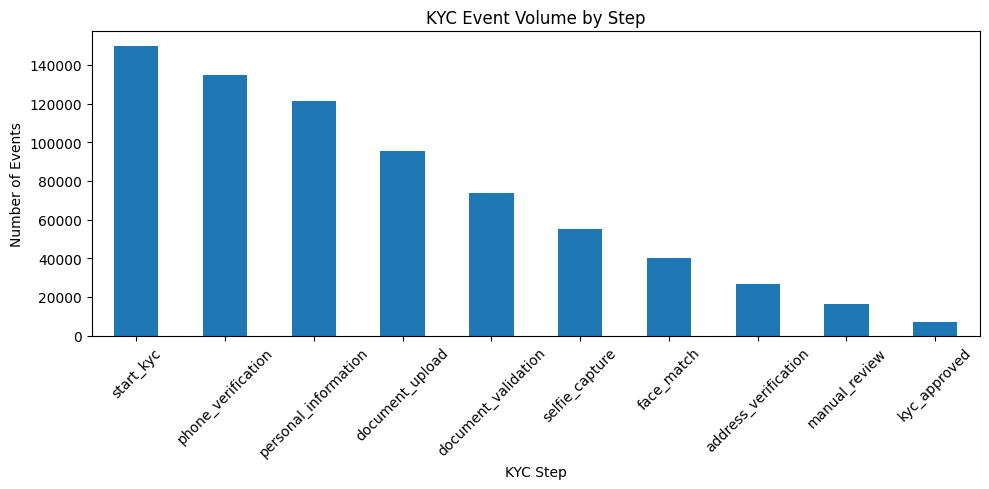

In [16]:
step_counts = base_events["kyc_step"].value_counts().sort_index()
print(step_counts)

step_counts.plot(kind="bar", figsize=(10, 5), title="KYC Event Volume by Step")
plt.xlabel("KYC Step")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Status Distribution**

status
success    539724
fail       108303
abandon     71985
Name: count, dtype: int64


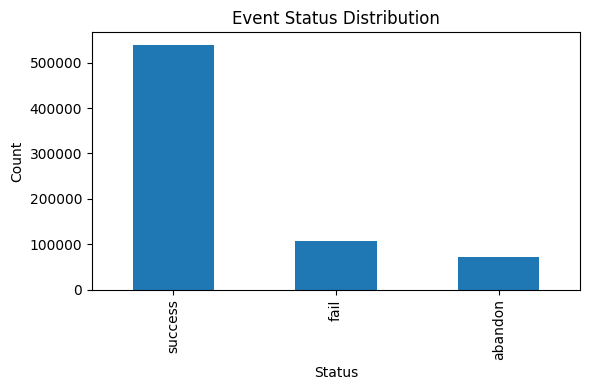

In [17]:
status_counts = base_events["status"].value_counts()
print(status_counts)

status_counts.plot(kind="bar", figsize=(6, 4), title="Event Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### **Duration Distribution**

count    720012.000000
mean         62.014137
std          33.211493
min           5.000000
25%          33.000000
50%          62.000000
75%          91.000000
max         119.000000
Name: duration_seconds, dtype: float64


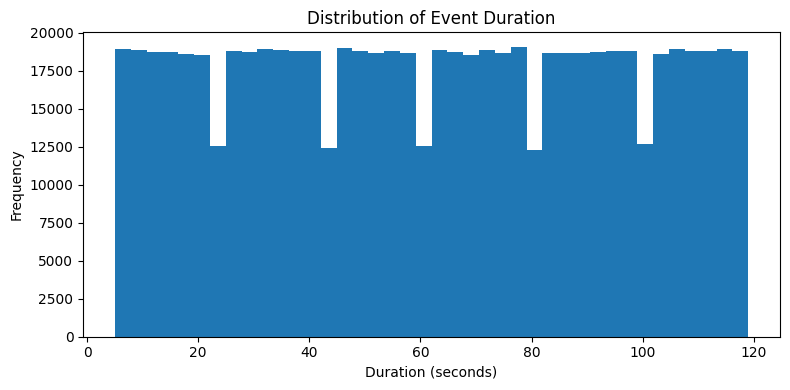

In [18]:
print(base_events["duration_seconds"].describe())

base_events["duration_seconds"].plot(
    kind="hist",
    bins=40,
    figsize=(8, 4),
    title="Distribution of Event Duration"
)
plt.xlabel("Duration (seconds)")
plt.tight_layout()
plt.show()

#### **Retry Count Distribution**

count    720012.000000
mean          0.998485
std           0.815998
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           2.000000
Name: retry_count, dtype: float64


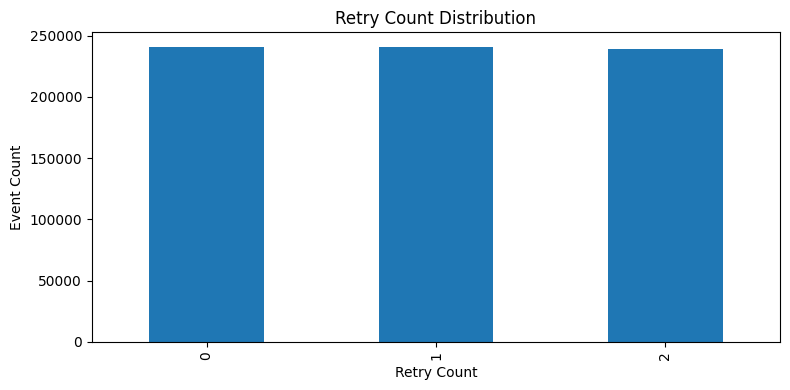

In [19]:
print(base_events["retry_count"].describe())

base_events["retry_count"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 4),
    title="Retry Count Distribution"
)
plt.xlabel("Retry Count")
plt.ylabel("Event Count")
plt.tight_layout()
plt.show()

A few interesting patterns stood out:
- durations are fairly similar across steps
- retry counts are also fairly uniform

This suggests that the dataset is strongest for funnel and segmentation analysis. Also duration/retry may still be useful, but should not be overinterpreted.

#### **Packet Loss Distribution**

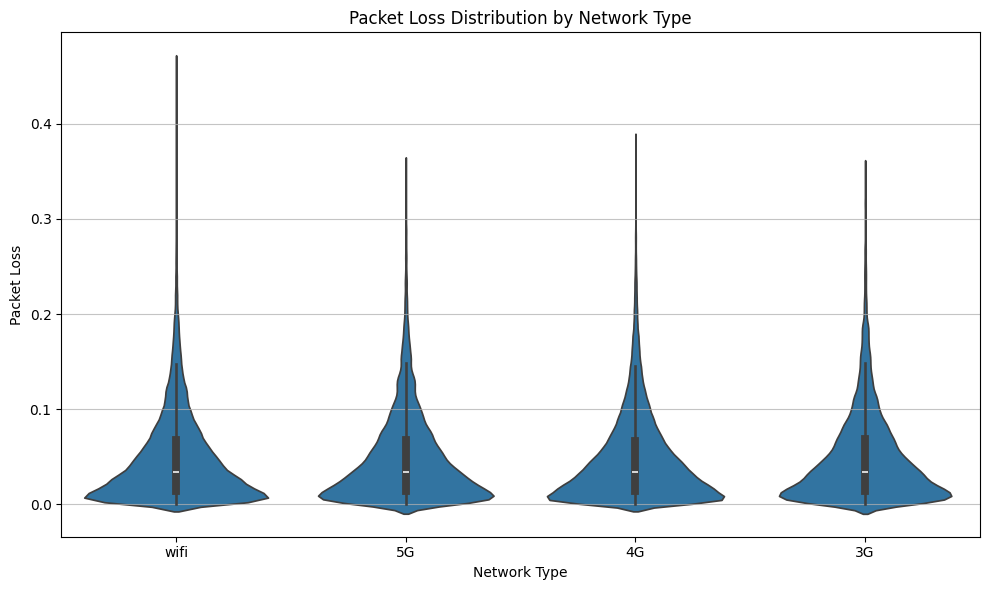

In [20]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='network_type', y='packet_loss', data=base_events)
plt.title('Packet Loss Distribution by Network Type')
plt.xlabel('Network Type')
plt.ylabel('Packet Loss')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

The violin plot shows the distribution of `packet_loss` across different `network_type` categories, highlighting how packet loss varies by connectivity type. The width of each violin represents the density of observations, allowing us to see the typical packet loss levels, the variability within each network type, and the presence of any extreme values.

#### **Upload Speed Distribution**

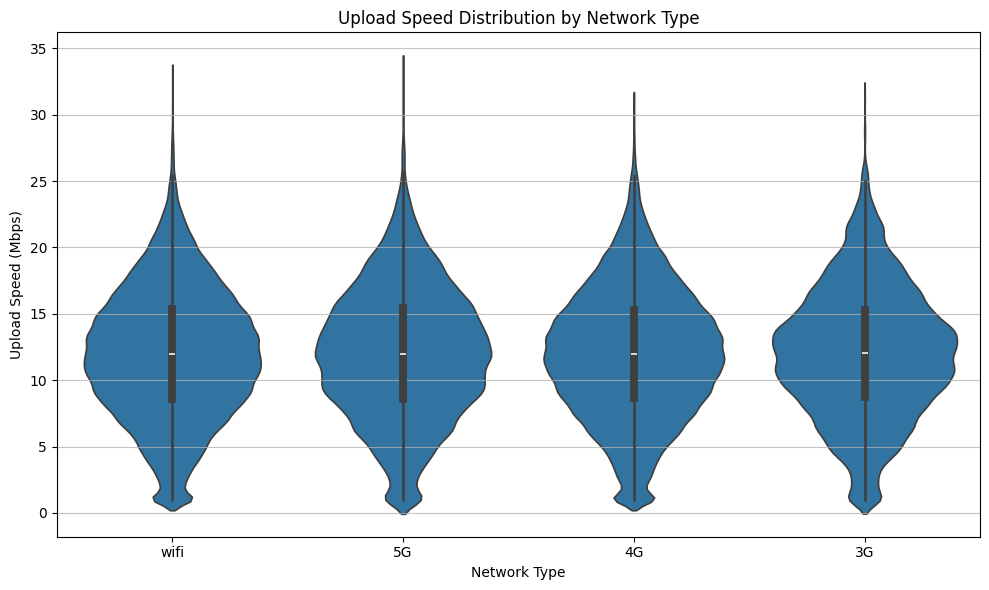

In [21]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='network_type', y='upload_speed_mbps', data=base_events)
plt.title('Upload Speed Distribution by Network Type')
plt.xlabel('Network Type')
plt.ylabel('Upload Speed (Mbps)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

The violin plot shows the distribution of `upload_speed_mbps` across different `network_type` categories, illustrating how upload speeds vary depending on the type of connection. The width of each violin represents the density of observations, helping visualize the most common upload speeds, the variability within each network type, and any extreme values.

**Combined Network Performance — Packet Loss & Upload Speed**

The violin plots for packet_loss and upload_speed_mbps across different network_type categories highlight meaningful differences in network reliability and performance.
- 4G and WiFi networks show broader distributions for both upload speed and packet loss. This indicates greater variability in user experience, likely influenced by factors such as location, signal strength, network congestion, or router quality. While these networks can provide strong performance, their variability suggests that some users may still experience unstable connections.
- The 3G network displays a more concentrated distribution with lower upload speeds and potentially higher packet loss, reflecting the limitations of older network infrastructure. This suggests that users on 3G are more likely to experience slower uploads and connectivity instability, which may contribute to failures during upload-heavy KYC steps such as document submission or selfie capture.
- 5G networks generally show higher upload speeds and lower packet loss, with distributions skewed toward better performance. This indicates a more stable and efficient connection environment, which supports smoother document uploads and biometric verification processes.

**Key implication:**
- Network performance plays an important role in the KYC experience. Faster and more stable connections (such as 5G) are likely to support smoother onboarding, while slower or less reliable networks (such as 3G or variable WiFi conditions) may increase the likelihood of upload failures, retries, or abandonment during verification steps.

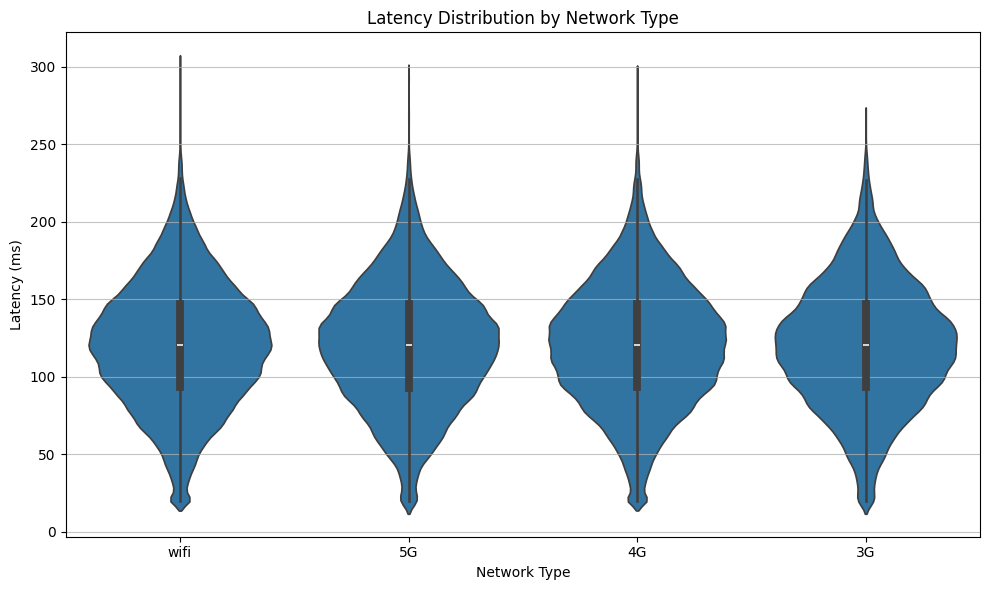

In [22]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='network_type', y='latency_ms', data=base_events)
plt.title('Latency Distribution by Network Type')
plt.xlabel('Network Type')
plt.ylabel('Latency (ms)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

This violin plot shows the distribution of `latency_ms` for each `network_type`. The width of each violin indicates the density of data points at different latency values. We can see the comparison of the typical latency, spread, and presence of outliers for each network type at a glance.

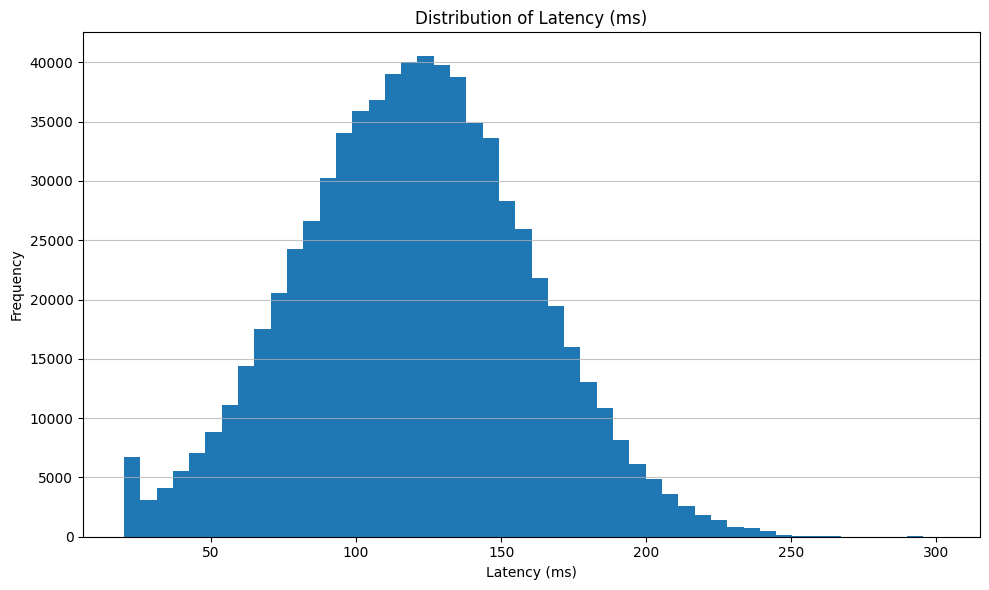

In [23]:
plt.figure(figsize=(10, 6))
base_events['latency_ms'].plot(
    kind='hist',
    bins=50, # Using 50 bins for a detailed view
    title='Distribution of Latency (ms)',
    xlabel='Latency (ms)',
    ylabel='Frequency'
)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

#### **Visualize the KYC event status by step**
Display the proportion of 'success', 'fail', and 'abandon' statuses for each KYC step.



In [24]:
status_by_step = base_events.groupby(['kyc_step', 'status']).size().unstack(fill_value=0)
status_proportions = status_by_step.div(status_by_step.sum(axis=1), axis=0)
print(status_proportions.head())

status                 abandon      fail   success
kyc_step                                          
start_kyc             0.099939  0.150656  0.749404
phone_verification    0.101116  0.150851  0.748033
personal_information  0.099384  0.150829  0.749788
document_upload       0.100123  0.150194  0.749683
document_validation   0.098781  0.151063  0.750156


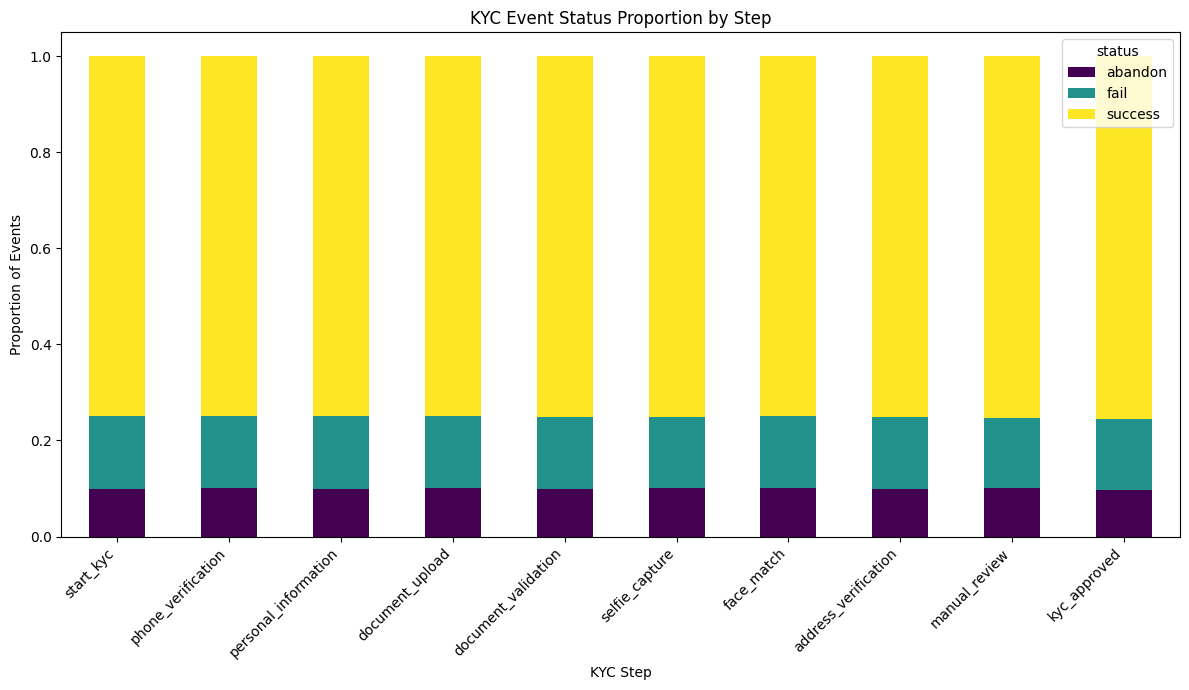

In [25]:
status_proportions.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')
plt.title('KYC Event Status Proportion by Step')
plt.xlabel('KYC Step')
plt.ylabel('Proportion of Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Status Distribution across KYC Steps**

The visualization shows that the proportions of success, fail, and abandon outcomes are relatively consistent across most steps. This suggests that the issues affecting completion are likely systemic across the overall onboarding experience rather than isolated to a single step.

Across nearly all steps, success remains the dominant outcome, indicating that the majority of KYC interactions are successfully completed. However, proportional consistency does not necessarily imply equal impact. Steps with a larger volume of events may still generate a higher absolute number of failures or abandonments, even if their proportional rates appear similar to other steps.

**Key Insights**
- Similar status proportions across steps indicate that failures and abandonment may stem from broader factors such as user experience complexity, technical reliability, or user behavior patterns.
- Most KYC events end successfully, suggesting that the process is generally functioning as intended.
- Steps with the highest event volumes should be prioritized for optimization, as even small improvements in their success rates could significantly reduce overall user drop-off.

**Next steps**

To better diagnose the causes of failures and abandonment:
- Analyze absolute failure and abandonment counts at each step to identify where the largest user losses occur.
- Investigate error codes by step to pinpoint the most common technical issues (e.g., blurry_document, face_mismatch).
- Perform user segmentation analysis to determine whether specific user groups (e.g., by country, device type, or network quality) are more likely to abandon the process.
- Examine duration effects, testing whether longer step durations correlate with higher failure or abandonment rates.
- Conduct multivariate analysis to evaluate how user, device, and network characteristics interact to influence KYC outcomes.

**Calculate Absolute Failure and Abandonment Counts**

In [26]:
filtered_events = base_events[base_events['status'].isin(['fail', 'abandon'])]
absolute_status_counts = filtered_events.groupby(['kyc_step', 'status']).size().unstack(fill_value=0)
print("Absolute counts of 'fail' and 'abandon' statuses by KYC step:")
print(absolute_status_counts.head())

Absolute counts of 'fail' and 'abandon' statuses by KYC step:
status                abandon   fail
kyc_step                            
start_kyc               14976  22576
phone_verification      13638  20346
personal_information    12049  18286
document_upload          9554  14332
document_validation      7274  11124


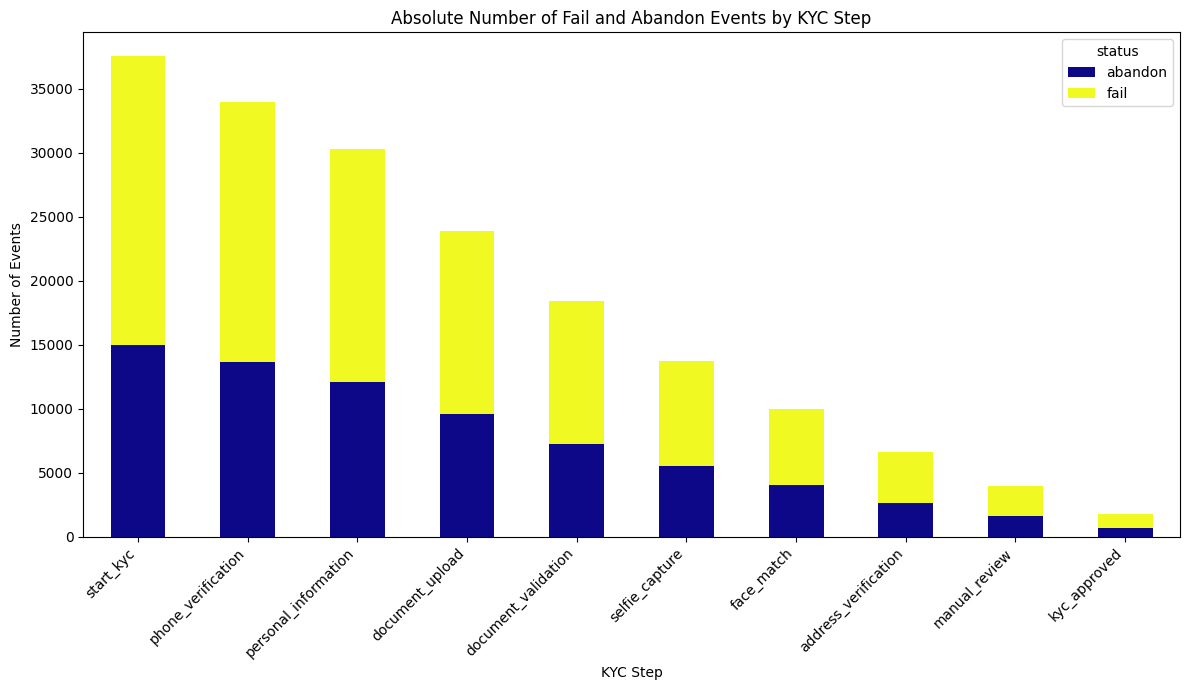

In [27]:
absolute_status_counts.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='plasma')
plt.title('Absolute Number of Fail and Abandon Events by KYC Step')
plt.xlabel('KYC Step')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Absolute Failure & Abandonment:**
- The analysis of absolute event counts shows that start_kyc and phone_verification generate the highest number of failures and abandonments in the KYC funnel. For example, start_kyc recorded 19,703 failures and 13,138 abandonments, indicating that a large number of users encounter issues at the very beginning of the onboarding process.
- While proportional analysis helps identify steps with high failure rates, absolute counts reveal where the largest volumes of affected users occur. This means that even if early steps do not have the highest failure percentages, their large traffic volume makes them critical bottlenecks.

**Key implication:**
- Improvement efforts should prioritize high-volume steps such as start_kyc and phone_verification, since even small increases in success at these stages could significantly reduce overall KYC drop-offs and improve funnel conversion.

**Most prevalent error codes for 'fail' events by KYC step**

In [28]:
failed_events_with_errors = base_events[base_events['status'] == 'fail'].dropna(subset=['error_code'])
error_counts_by_step = failed_events_with_errors.groupby(['kyc_step', 'error_code']).size().unstack(fill_value=0)

print("Most prevalent error codes for 'fail' events by KYC step:")
print(error_counts_by_step.head())

Most prevalent error codes for 'fail' events by KYC step:
error_code            blurry_document  document_rejected  face_mismatch  network_timeout
kyc_step                                                                                
start_kyc                        4493               4605           4566             4503
phone_verification               4073               4029           4178             4047
personal_information             3498               3733           3778             3641
document_upload                  2809               2875           2818             2946
document_validation              2204               2165           2271             2268


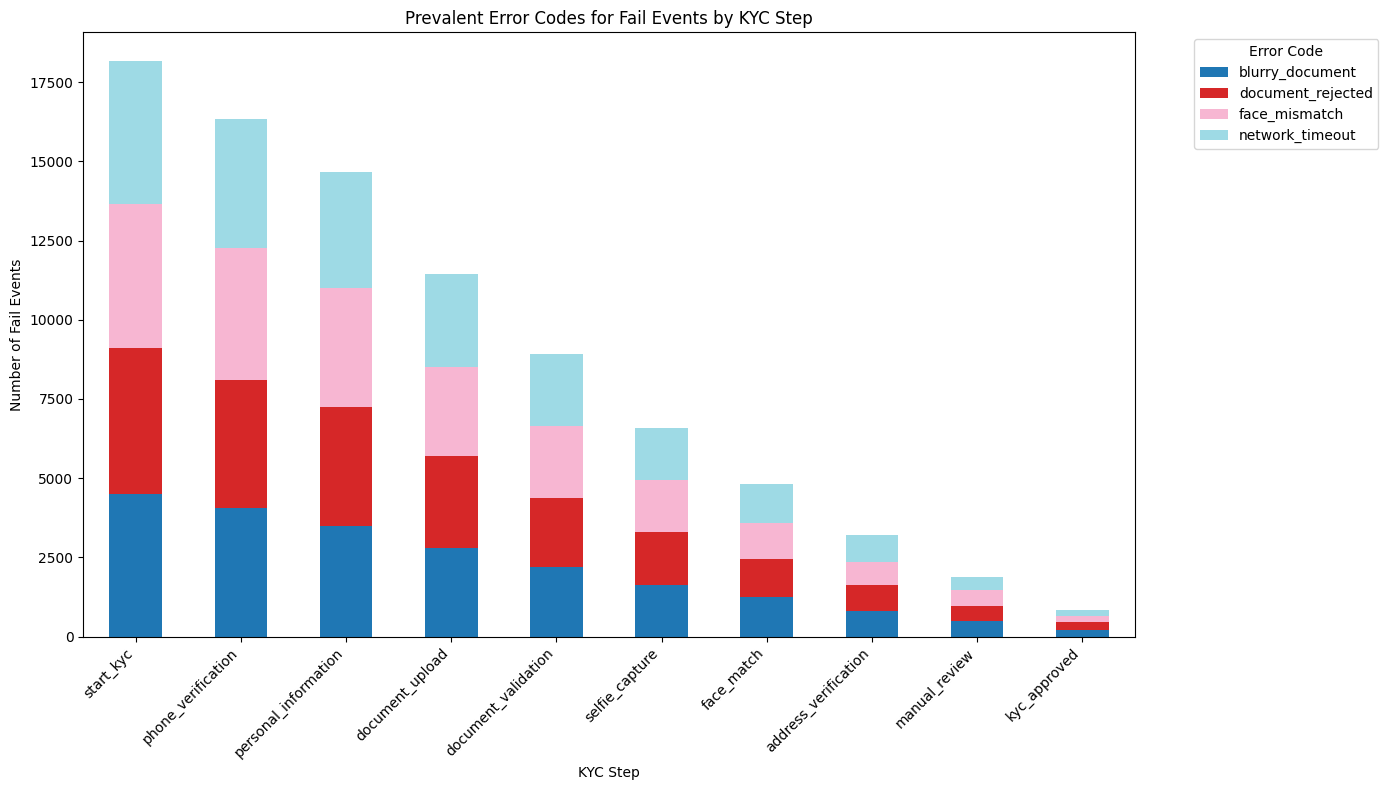

In [29]:
error_counts_by_step.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='tab20')
plt.title('Prevalent Error Codes for Fail Events by KYC Step')
plt.xlabel('KYC Step')
plt.ylabel('Number of Fail Events')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Error Code', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Error Code Analysis:**
- The error code analysis shows that the most common reasons for KYC failures are blurry_document, document_rejected, face_mismatch, and network_timeout. These errors appear across multiple KYC steps, although their absolute frequency decreases as users progress further through the verification process.
- Unlike proportional or absolute failure counts that indicate where issues occur, error code analysis reveals why those failures happen. This provides more granular insight into the technical or user-experience problems affecting the KYC journey.

**Key implication:**

Improvement efforts should focus on addressing these specific error types. Potential solutions include improving document capture guidance to reduce blurry documents, enhancing validation systems to minimize document rejection, providing clearer instructions for selfie/face capture, and optimizing upload processes to reduce network-related failures.

**Summary:**
* The `start_kyc` and `phone_verification` steps generate the highest absolute numbers of failures and abandonments, making them key bottlenecks in the onboarding funnel. The start_kyc step alone recorded 19,703 failures and 13,138 abandonments.
* The most common error codes driving failures across the KYC process are `blurry_document`, `document_rejected`, `face_mismatch`, and `network_timeout`.
* While these error types appear across multiple steps, their absolute frequency decreases as users progress through the funnel, reflecting the natural drop-off of users at earlier stages.
* Across most KYC steps, failures occur more frequently than abandonments, indicating that technical or validation issues are a more significant barrier than voluntary user drop-off.

**Insights / Next Steps**
- Prioritize improvements at early high-volume steps, particularly `start_kyc` and `phone_verification`, as even small improvements here could reduce failures for a large number of users.
- Address the most common technical failure causes by implementing targeted solutions such as improved document capture guidance to reduce `blurry_document` errors, clearer biometric capture instructions to minimize `face_mismatch`, and better upload reliability or connectivity handling to mitigate `network_timeout` issues.


# **Stage 6: Funnel Analysis - Core Metrics**

Core funnel analysis to identify drop-off points.
Calculate:
- How many users reached each step
- Step completion rates
- Drop-off counts and rates
- Last observed step for each user

In [30]:
# Show the correct funnel order
funnel_steps

['start_kyc',
 'phone_verification',
 'personal_information',
 'document_upload',
 'document_validation',
 'selfie_capture',
 'face_match',
 'address_verification',
 'manual_review',
 'kyc_approved']

In [31]:
# Unique users who reached each step
funnel_reach = (
    base_events.groupby("kyc_step")["user_id"]
    .nunique()
    .reindex(funnel_steps)
    .reset_index(name="users_reached")
)
funnel_reach


,kyc_step,users_reached
0,start_kyc,100000
1,phone_verification,94588
2,personal_information,88636
3,document_upload,75294
4,document_validation,61687
5,selfie_capture,48399
6,face_match,36258
7,address_verification,25032
8,manual_review,15415
9,kyc_approved,7067


In [32]:
# funnel chart visualising number of users who reached each step of the KYC funnel
import plotly.express as px

# Create a new column with values in 'K' and formatted to one decimal point
funnel_reach['users_reached_k'] = (funnel_reach['users_reached'] / 1000).round(1)

# Create the funnel chart using px.funnel
fig = px.funnel(funnel_reach, x='users_reached', y='kyc_step', title='Users Reached Each Step')

# Update traces to show the new 'users_reached_k' with 'K' suffix
fig.update_traces(texttemplate=funnel_reach['users_reached_k'].astype(str) + 'K')

# Display the chart
fig.show()

In [33]:
print("\n--- Funnel Step Metrics ---")
funnel_data = []

for step in funnel_steps:
    # Users who have any event for this step
    users_reached = base_events[base_events['kyc_step'] == step]['user_id'].nunique()

    # Users who succeeded at this step
    users_succeeded = base_events[
        (base_events['kyc_step'] == step) &
        (base_events['status'] == 'success')
    ]['user_id'].nunique()

    # Users who failed at this step (as final outcome)
    users_failed = base_events[
        (base_events['kyc_step'] == step) &
        (base_events['status'] == 'fail')
    ]['user_id'].nunique()

    # Users who abandoned at this step (as final outcome)
    users_abandoned = base_events[
        (base_events['kyc_step'] == step) &
        (base_events['status'] == 'abandon')
    ]['user_id'].nunique()

    funnel_data.append({
        'step': step,
        'users_reached': users_reached,
        'users_succeeded': users_succeeded,
        'users_failed': users_failed,
        'users_abandoned': users_abandoned
    })

funnel_df = pd.DataFrame(funnel_data)
print(funnel_df)


--- Funnel Step Metrics ---
                   step  users_reached  users_succeeded  users_failed  users_abandoned
0             start_kyc         100000            84381         21460            14481
1    phone_verification          94588            78254         19462            13217
2  personal_information          88636            72582         17539            11739
3       document_upload          75294            60208         13884             9338
4   document_validation          61687            48500         10857             7177
5        selfie_capture          48399            37516          8098             5469
6            face_match          36258            27826          5899             3978
7  address_verification          25032            19151          3939             2629
8         manual_review          15415            11705          2353             1603
9          kyc_approved           7067             5367          1058              701


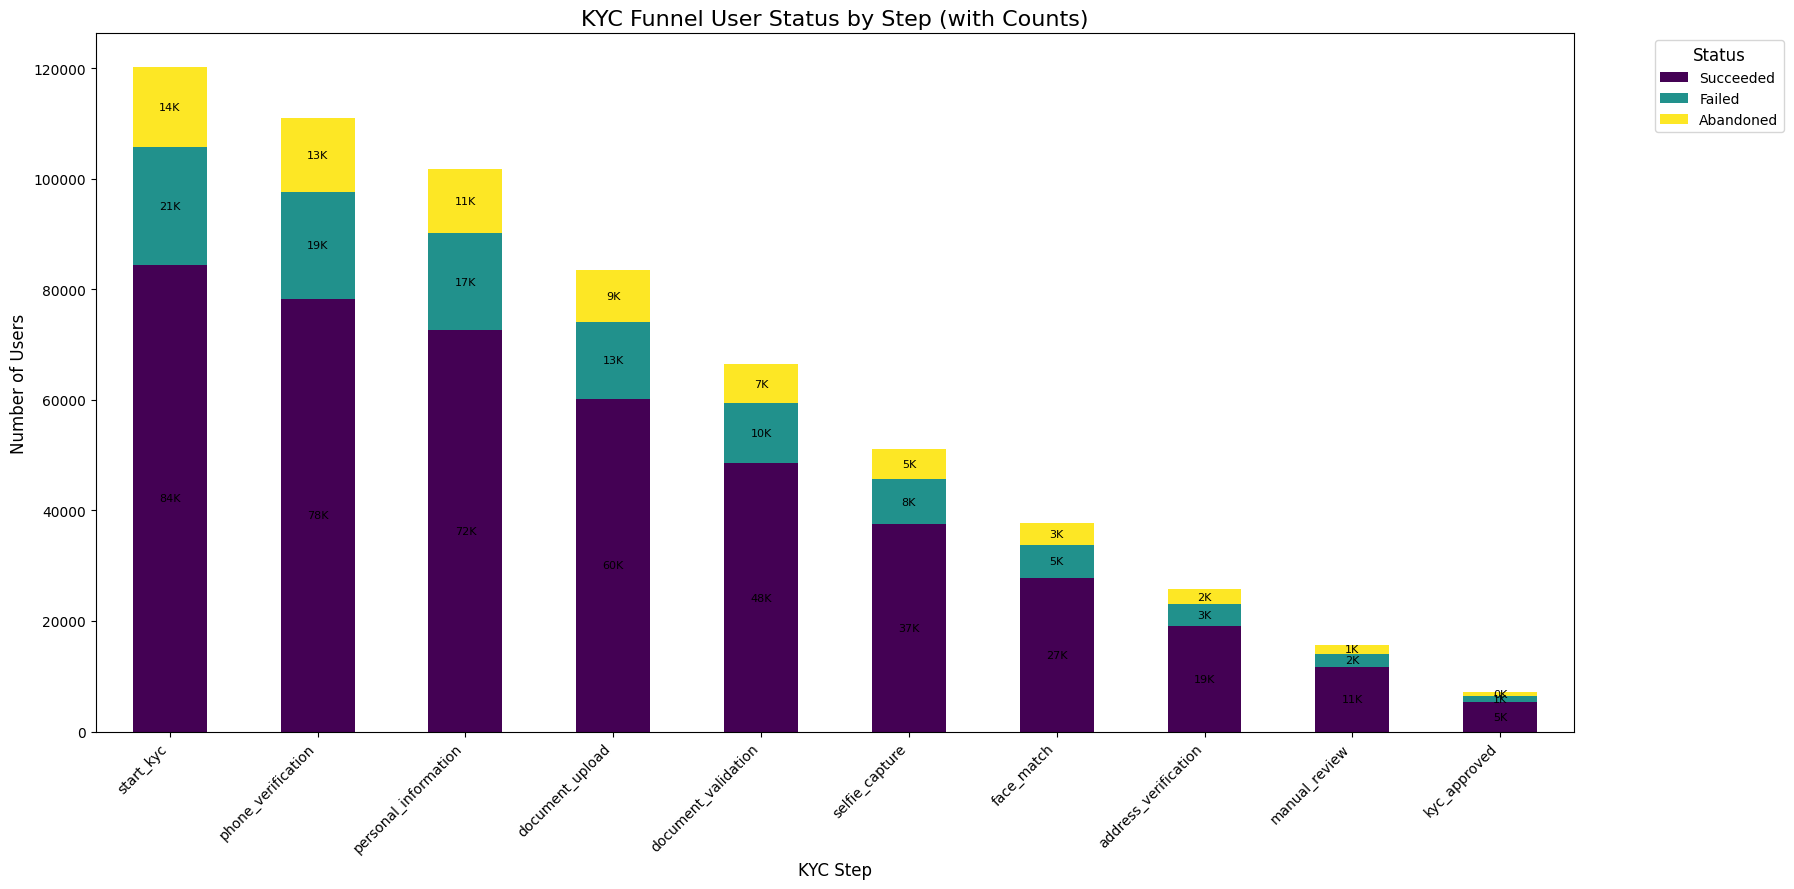

In [34]:
funnel_df_plot = funnel_df.set_index('step')
ax = funnel_df_plot[['users_succeeded', 'users_failed', 'users_abandoned']].plot(kind='bar', stacked=True, figsize=(18, 9), cmap='viridis')

plt.title('KYC Funnel User Status by Step (with Counts)', fontsize=16)
plt.xlabel('KYC Step', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(['Succeeded', 'Failed', 'Abandoned'], title='Status', fontsize=10, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

# Add labels to each segment, formatted with 'K' for thousands
for container in ax.containers:
    labels = [f'{int(v.get_height()/1000)}K' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

In [35]:
# Melt and divide for 'k' format
funnel_melted = funnel_df.melt(
    id_vars='step',
    value_vars=['users_succeeded', 'users_failed', 'users_abandoned'],
    var_name='status',
    value_name='count'
)
funnel_melted['count_k'] = funnel_melted['count'] / 1000

# Assign your specific colors
color_map = {
    'users_succeeded': 'green',
    'users_failed': 'red',
    'users_abandoned': 'blue'
}

# Create the funnel chart
fig = px.funnel(
    funnel_melted,
    x='count_k',
    y='step',
    color='status',
    title='KYC Funnel User Status by Step',
    color_discrete_map=color_map
)

# Format for 1 decimal point, 'k' suffix
fig.update_traces(
    texttemplate="%{x:.1f}k",
    insidetextfont=dict(size=10) # Adjust '10' to make it smaller or larger
)

fig.show()


In [36]:
# Calculate conversion rates
total_users = len(users)
funnel_df['reach_rate'] = (funnel_df['users_reached'] / total_users * 100).round(1)
funnel_df['success_rate'] = (funnel_df['users_succeeded'] / total_users * 100).round(1)
funnel_df['drop_off'] = funnel_df['users_reached'] - funnel_df['users_succeeded'].shift(1, fill_value=funnel_df['users_reached'].iloc[0])
funnel_df['drop_off_rate'] = (funnel_df['drop_off'] / funnel_df['users_reached'] * 100).round(1)

print("\nFunnel Summary Table:")
print(funnel_df[['step', 'users_reached', 'users_succeeded', 'reach_rate', 'success_rate', 'drop_off', 'drop_off_rate']])


Funnel Summary Table:
                   step  users_reached  users_succeeded  reach_rate  success_rate  drop_off  drop_off_rate
0             start_kyc         100000            84381       100.0          84.4         0            0.0
1    phone_verification          94588            78254        94.6          78.3     10207           10.8
2  personal_information          88636            72582        88.6          72.6     10382           11.7
3       document_upload          75294            60208        75.3          60.2      2712            3.6
4   document_validation          61687            48500        61.7          48.5      1479            2.4
5        selfie_capture          48399            37516        48.4          37.5      -101           -0.2
6            face_match          36258            27826        36.3          27.8     -1258           -3.5
7  address_verification          25032            19151        25.0          19.2     -2794          -11.2
8         manu

**Summary of the KYC funnel conversion analysis:**

- The overall conversion is low. Only 5.4% of the initial 100,000 users successfully complete the entire KYC process (reaching kyc_approved). This indicates a significant opportunity for improvement.
- The major bottlenecks are at the early stages. The most substantial absolute user drop-offs occuring between start_kyc & phone_verification, and phone_verification & personal_information. These early steps are critical points as users are leaving the funnel in large numbers.
- The reach_rate shows the proportion of initial users who simply started a step, while success_rate indicates those who successfully completed it relative to the total initial users. As observed, there is a consistent decline in both rates throughout the funnel.
- While the calculated drop_off metric (users lost between succeeding the previous step and reaching the current one) shows negative values for later stages, this actually signifies a continuous loss of users. The largest volumes of users are lost at the very beginning of the process.

The KYC process faces significant user attrition, particularly in its initial stages. Addressing the reasons for drop-offs at start_kyc and phone_verification would likely yield the greatest impact on improving overall conversion rates.

In [37]:
# Calculate step-to-step conversion
step_to_step_conversions = []

for i in range(len(funnel_steps)-1):
    current_step = funnel_steps[i]
    next_step = funnel_steps[i+1]

    users_current = funnel_df[funnel_df['step'] == current_step]['users_succeeded'].values[0]
    users_next = funnel_df[funnel_df['step'] == next_step]['users_reached'].values[0]

    conversion = None
    if users_current > 0:
        conversion = (users_next / users_current * 100).round(1)

    step_to_step_conversions.append({
        'from_step': current_step,
        'to_step': next_step,
        'users_succeeded_from_step': users_current,
        'users_reached_to_step': users_next,
        'conversion_rate (%)': conversion
    })

step_to_step_df = pd.DataFrame(step_to_step_conversions)
print("\nStep-to-Step Conversion Table")
print(step_to_step_df)


Step-to-Step Conversion Table
              from_step               to_step  users_succeeded_from_step  users_reached_to_step  conversion_rate (%)
0             start_kyc    phone_verification                      84381                  94588                112.1
1    phone_verification  personal_information                      78254                  88636                113.3
2  personal_information       document_upload                      72582                  75294                103.7
3       document_upload   document_validation                      60208                  61687                102.5
4   document_validation        selfie_capture                      48500                  48399                 99.8
5        selfie_capture            face_match                      37516                  36258                 96.6
6            face_match  address_verification                      27826                  25032                 90.0
7  address_verification         m

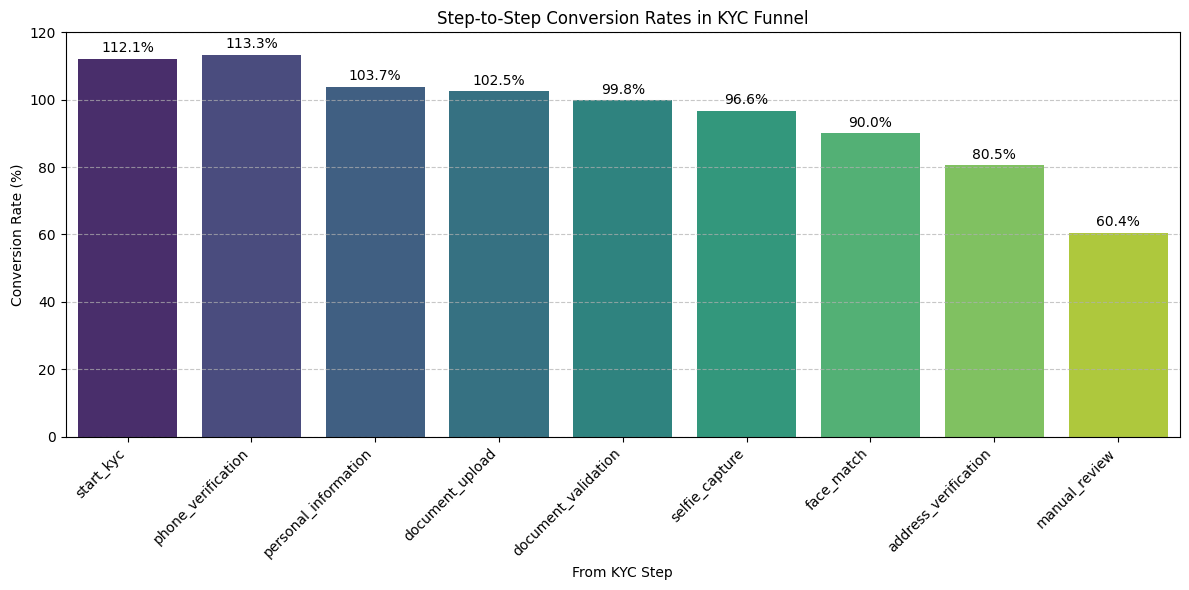

In [38]:
# visualize the step-to-step conversion rates
plt.figure(figsize=(12, 6))
sns.barplot(x='from_step', y='conversion_rate (%)', data=step_to_step_df, palette='viridis')
plt.title('Step-to-Step Conversion Rates in KYC Funnel')
plt.xlabel('From KYC Step')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 120) # Set y-axis limit to accommodate rates slightly above 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of the bars
for index, row in step_to_step_df.iterrows():
    plt.text(index, row['conversion_rate (%)'] + 2, f"{row['conversion_rate (%)']:.1f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

**Summary of the step-to-step conversion analysis:**

- The initial KYC steps (e.g., start_kyc to personal_information) show conversion rates above 100%. This indicates a non-linear user journey, possibly due to users re-entering the funnel, skipping steps, or broader definitions of 'reaching' a step versus strictly 'succeeding' the immediate prior one. This suggests flexibility or retry mechanisms are at play in the early stages.
- Steps in the middle of the KYC process, such as document_validation to selfie_capture, show conversion rates close to 100%, indicating relatively efficient transitions for users who reach these points.
- Conversion rates significantly decrease towards the end of the funnel. manual_review to kyc_approved stands out with the lowest conversion rate at 60.4%. This means nearly 40% of users who successfully complete the manual_review stage do not ultimately get approved. This is the most significant bottleneck for final approval.

**Conclusion:**

While the early funnel stages exhibit complex user flows that might mask immediate drop-offs, the later stages, particularly the final approval process after manual review, represent clear and substantial points of user attrition that warrant immediate investigation and optimization.

#### **Investigating >100% Conversion Rates**

To understand why some step-to-step conversion rates are above 100%, focus on a specific transition where this occurs, for example, from `start_kyc` to `phone_verification` (conversion rate of 112.1%).

This phenomenon implies that some users are *reaching* 'phone_verification' even though they did not *succeed* 'start_kyc'. This could be due to:
1.  Users failing/abandoning `start_kyc` but later retrying and moving forward within the same or a new session.
2.  Different entry points or non-linear user flows that allow users to reach 'phone_verification' without a recorded 'success' status for 'start_kyc'.

In [39]:
# 1. Get users who successfully completed 'start_kyc'
users_succeeded_start_kyc = set(base_events[
    (base_events['kyc_step'] == 'start_kyc') &
    (base_events['status'] == 'success')
]['user_id'].unique())

# 2. Get users who reached 'phone_verification' (any status for this step)
users_reached_phone_verification = set(base_events[
    (base_events['kyc_step'] == 'phone_verification')
]['user_id'].unique())

# 3. Find users who reached 'phone_verification' but did NOT succeed 'start_kyc'
users_reached_phone_verification_without_start_kyc_success = users_reached_phone_verification - users_succeeded_start_kyc

print(f"Number of users who succeeded 'start_kyc': {len(users_succeeded_start_kyc)}")
print(f"Number of users who reached 'phone_verification': {len(users_reached_phone_verification)}")
print(f"Number of users who reached 'phone_verification' but did NOT succeed 'start_kyc': {len(users_reached_phone_verification_without_start_kyc_success)}")

# 4. Display a few examples of such users and their event history
if len(users_reached_phone_verification_without_start_kyc_success) > 0:
    sample_users = list(users_reached_phone_verification_without_start_kyc_success)[:5]
    print("\nSample user IDs that reached 'phone_verification' without succeeding 'start_kyc':", sample_users)

    # Get all events for these sample users to understand their journey
    print("\nEvent history for sample users:")
    for user_id in sample_users:
        print(f"\n--- User: {user_id} ---")
        display(base_events[base_events['user_id'] == user_id][['session_id', 'kyc_step', 'status', 'event_id']].sort_values(['session_id', 'event_id']))
else:
    print("No users found who reached 'phone_verification' without succeeding 'start_kyc'.")

Number of users who succeeded 'start_kyc': 84381
Number of users who reached 'phone_verification': 94588
Number of users who reached 'phone_verification' but did NOT succeed 'start_kyc': 10207

Sample user IDs that reached 'phone_verification' without succeeding 'start_kyc': ['U0077235', 'U0058529', 'U0035167', 'U0038572', 'U0043907']

Event history for sample users:

--- User: U0077235 ---


,session_id,kyc_step,status,event_id
556150,S115719,start_kyc,fail,556151
556151,S115719,phone_verification,success,556152
556152,S115719,personal_information,success,556153
556153,S115719,document_upload,success,556154
556154,S115719,document_validation,success,556155
556155,S115719,selfie_capture,abandon,556156



--- User: U0058529 ---


,session_id,kyc_step,status,event_id
420727,S87586,start_kyc,fail,420728
420728,S87586,phone_verification,fail,420729
420729,S87586,personal_information,success,420730
420730,S87586,document_upload,success,420731
420731,S87586,document_validation,success,420732
420732,S87586,selfie_capture,success,420733
420733,S87586,face_match,success,420734
420734,S87586,address_verification,success,420735



--- User: U0035167 ---


,session_id,kyc_step,status,event_id
252571,S52670,start_kyc,fail,252572
252572,S52670,phone_verification,success,252573
252573,S52670,personal_information,success,252574
252574,S52670,document_upload,success,252575
252575,S52670,document_validation,success,252576
252576,S52670,selfie_capture,success,252577
252577,S52670,face_match,success,252578
252578,S52670,address_verification,fail,252579
252579,S52670,manual_review,success,252580
252580,S52671,start_kyc,fail,252581



--- User: U0038572 ---


,session_id,kyc_step,status,event_id
277012,S57755,start_kyc,fail,277013
277013,S57755,phone_verification,abandon,277014



--- User: U0043907 ---


,session_id,kyc_step,status,event_id
315284,S65747,start_kyc,fail,315285
315285,S65747,phone_verification,success,315286
315286,S65747,personal_information,success,315287
315287,S65747,document_upload,success,315288
315288,S65747,document_validation,success,315289
315289,S65747,selfie_capture,success,315290
315290,S65747,face_match,success,315291
315291,S65747,address_verification,fail,315292


**Why some conversion rates appear above 100%:**
Some step-to-step conversion rates appear above 100% because more users reached the next step than successfully completed the previous one. Specifically, 10,207 users reached phone_verification even though they did not successfully complete start_kyc. This causes the conversion calculation (users reaching the next step divided by users successfully completing the prior step) to exceed 100%.

**Why this happens:**

Inspection of individual user event histories shows that the KYC process allows non-linear user journeys. Users are not strictly required to successfully complete a step before moving to the next one. For example:
- User U0035816 failed start_kyc, but still progressed to phone_verification, succeeded there, and continued to personal_information before abandoning at document_upload. The same user also attempted start_kyc again in a later session.
- User U0025908 failed start_kyc but still reached phone_verification, where they later abandoned.

These examples demonstrate that failing or abandoning an early step does not always prevent users from proceeding to later steps.

**Key insight:**

The KYC process supports flexible, retry-based flows, where users may:
- fail a step but attempt the next one,
- retry steps across multiple sessions,
- re-enter the funnel at different points.

Because of this, the funnel measures how many unique users appear at each step, not strictly how many converted from a successful completion of the previous step.

Conversion rates above 100% are not an error but reflect the non-linear nature of the onboarding process. When interpreting funnel efficiency, it is important to consider that users may enter later steps through retries or alternate flows rather than a strict sequential progression.

**Last observed step analysis - where users stop**


In [40]:
base_events.columns

Index(['event_id', 'user_id', 'session_id', 'kyc_step', 'status', 'duration_seconds', 'retry_count', 'error_code',
       'session_start', 'derived_time_of_day', 'day_of_week', 'signup_time', 'age', 'country', 'acquisition_source',
       'fraud_risk_score', 'signup_date', 'age_band', 'fraud_risk_bucket', 'device_type', 'os', 'device_model',
       'camera_quality_score', 'camera_quality_bucket', 'network_type', 'latency_ms', 'packet_loss',
       'upload_speed_mbps', 'latency_bucket', 'upload_speed_bucket'],
      dtype='object')

In [41]:
# Get the last event for each user, sorting by session_start to determine the 'last' chronologically
last_events = base_events.sort_values('session_start').groupby('user_id').last().reset_index()

# Filter to only non-approved final steps using the correct column name 'kyc_step'
last_step_dist = last_events[last_events['kyc_step'] != 'kyc_approved']['kyc_step'].value_counts()
print("\nUsers who stopped at each step (excluding approved):")
for step, count in last_step_dist.items():
    pct = round((count / total_users * 100), 1)
    print(f"  {step}: {count} users ({pct}%)")


Users who stopped at each step (excluding approved):
  start_kyc: 33647 users (33.6%)
  phone_verification: 19100 users (19.1%)
  personal_information: 16145 users (16.1%)
  document_upload: 10994 users (11.0%)
  document_validation: 7604 users (7.6%)
  selfie_capture: 5173 users (5.2%)
  face_match: 3402 users (3.4%)
  address_verification: 2098 users (2.1%)
  manual_review: 1232 users (1.2%)
  kyc_approved: 0 users (0.0%)


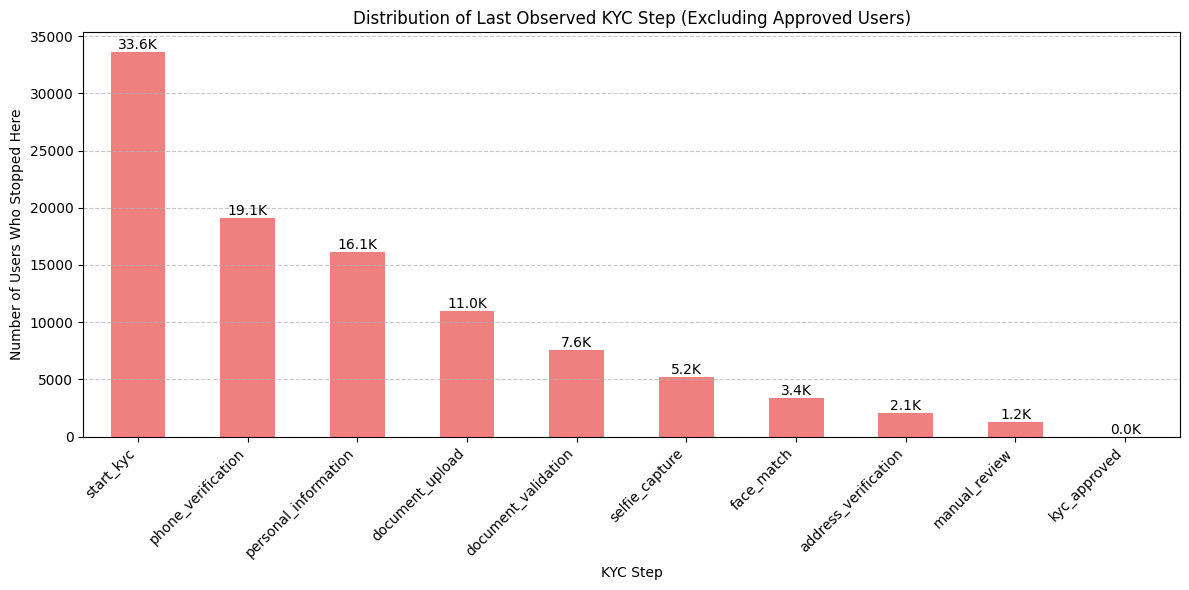

In [42]:
plt.figure(figsize=(12, 6))
ax = last_step_dist.plot(kind='bar', color='lightcoral')
plt.title('Distribution of Last Observed KYC Step (Excluding Approved Users)')
plt.xlabel('KYC Step')
plt.ylabel('Number of Users Who Stopped Here')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar, formatted in thousands
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x/1000:.1f}K')

plt.tight_layout()
plt.show()

- The vast majority of users who don't complete the KYC process are stopping at very early stages:  start_kyc, phone_verification, and personal_information steps
- The numbers progressively decrease as users move further down the funnel, making it evident that if users overcome the initial barriers, they are more likely to proceed.



In [43]:
# Success vs Failure summary
completed_users = last_events[last_events['kyc_step'] == 'kyc_approved']['user_id'].nunique()
failed_users = last_events[last_events['status'] == 'fail']['user_id'].nunique()
abandoned_users = last_events[last_events['status'] == 'abandon']['user_id'].nunique()

print(f"KYC Completed: {completed_users} ({completed_users/total_users*100:.1f}%)")
print(f"Failed (never retried successfully): {failed_users} ({failed_users/total_users*100:.1f}%)")
print(f"Abandoned: {abandoned_users} ({abandoned_users/total_users*100:.1f}%)")

KYC Completed: 605 (0.6%)
Failed (never retried successfully): 13062 (13.1%)
Abandoned: 22191 (22.2%)


- Extremely low completion rate: Only 0.6% (605 users) successfully complete the entire KYC process. This indicates a severe overall conversion problem.
- Significant user attrition: A combined 35.3% of users do not complete KYC due to their final state being either a failure (13.1%) or an abandonment (22.2%).

In this case, failures represent unrecoverable issues, while abandonments point to user disengagement, process difficulty, or loss of interest. KYC process is losing a vast majority of users long before final approval, highlighting a critical need for optimization to improve user experience and address technical barriers.

# **Stage 7: Root Cause Analysis**
Root cause analysis to identify why users drop off:
1. Document-related friction (upload, validation)
2. Technical friction (network, camera)
3. Process friction (forms, verification)
4. Session behavior patterns

**1. Document friction analysis**

In [44]:
document_steps = ['document_upload', 'document_validation']
doc_events = base_events[base_events['kyc_step'].isin(document_steps)]

print("\nDocument Step Failure Analysis:")
doc_failures = doc_events[doc_events['status'] == 'fail']
if not doc_failures.empty:
    print("\nError codes in document steps:")
    print(doc_failures['error_code'].value_counts())

print("\nDocument Step Retry Patterns:")
for step in document_steps:
    step_data = doc_events[doc_events['kyc_step'] == step]
    avg_retries = step_data['retry_count'].mean()
    max_retries = step_data['retry_count'].max()
    print(f"  {step}: avg retries = {avg_retries:.2f}, max retries = {max_retries}")

print("\nDocument Step Duration (seconds):")
for step in document_steps:
    step_data = doc_events[doc_events['kyc_step'] == step]
    avg_duration = step_data['duration_seconds'].mean()
    median_duration = step_data['duration_seconds'].median()
    print(f"  {step}: avg = {avg_duration:.0f}, median = {median_duration:.0f}")


Document Step Failure Analysis:

Error codes in document steps:
error_code
network_timeout      5214
face_mismatch        5089
document_rejected    5040
blurry_document      5013
Name: count, dtype: int64

Document Step Retry Patterns:
  document_upload: avg retries = 1.00, max retries = 2
  document_validation: avg retries = 1.00, max retries = 2

Document Step Duration (seconds):
  document_upload: avg = 62, median = 62
  document_validation: avg = 62, median = 62


**2. Technical friction analysis**

In [45]:
technical_steps = ['document_upload', 'document_validation', 'selfie_capture', 'face_match']
tech_events = base_events[base_events['kyc_step'].isin(technical_steps)]

print("\nImpact of Network Type:")
network_failure = tech_events.groupby('network_type')['status'].apply(
    lambda x: (x == 'fail').mean() * 100
).round(1)
print(network_failure)

print("\nImpact of Camera Quality:")
camera_failure = tech_events.groupby('camera_quality_bucket')['status'].apply(
    lambda x: (x == 'fail').mean() * 100
).round(1)
print(camera_failure)

print("\nImpact of Latency:")
latency_failure = tech_events.groupby('latency_bucket')['status'].apply(
    lambda x: (x == 'fail').mean() * 100
).round(1)
print(latency_failure)

print("\nImpact of Upload Speed:")
speed_failure = tech_events.groupby('upload_speed_bucket')['status'].apply(
    lambda x: (x == 'fail').mean() * 100
).round(1)
print(speed_failure)


Impact of Network Type:
network_type
3G      15.3
4G      14.8
5G      15.3
wifi    15.1
Name: status, dtype: float64

Impact of Camera Quality:
camera_quality_bucket
Low       15.0
Medium     NaN
High       NaN
Name: status, dtype: float64

Impact of Latency:
latency_bucket
low_latency       14.9
medium_latency    15.1
high_latency      14.9
Name: status, dtype: float64

Impact of Upload Speed:
upload_speed_bucket
slow        15.2
moderate    15.0
fast        15.1
Name: status, dtype: float64


**3. Process friction analysis**

In [46]:
process_steps = ['phone_verification', 'personal_information', 'address_verification']
process_events = base_events[base_events['kyc_step'].isin(process_steps)]

print("\nProcess Step Durations (seconds):")
for step in process_steps:
    step_data = process_events[process_events['kyc_step'] == step]
    if not step_data.empty:
        avg_duration = step_data['duration_seconds'].mean()
        median_duration = step_data['duration_seconds'].median()
        print(f"  {step}: avg = {avg_duration:.0f}, median = {median_duration:.0f}")

print("\nProcess Step Abandonment Rate:")
for step in process_steps:
    step_data = process_events[process_events['kyc_step'] == step]
    if not step_data.empty:
        abandon_rate = (step_data['status'] == 'abandon').mean() * 100
        print(f"  {step}: {abandon_rate:.1f}%")


Process Step Durations (seconds):
  phone_verification: avg = 62, median = 62
  personal_information: avg = 62, median = 62
  address_verification: avg = 62, median = 62

Process Step Abandonment Rate:
  phone_verification: 10.1%
  personal_information: 9.9%
  address_verification: 9.9%


**4. Session behavior analysis**

**Adding `session_end` to the `sessions` DataFrame**

Since the original `sessions` data does not contain a `session_end` column, we can derive it from the `kyc_events` data (which is already joined into `base_events`). We'll assume a session ends when the *last event within that session completes*. This involves:

1.  Calculating the end time for each individual event in `base_events` (i.e., `session_start` + `duration_seconds`).
2.  Grouping by `session_id` and `user_id` to find the maximum event end time for each session.
3.  Merging this calculated `session_end` back into the `sessions` DataFrame.

In [47]:
# Calculate event_end_time for each event in base_events
# First, ensure duration_seconds is in timedelta format to add to datetime
base_events['event_end_time'] = base_events['session_start'] + pd.to_timedelta(base_events['duration_seconds'], unit='s')

# Group by session and user to find the maximum event_end_time for each session
session_ends = base_events.groupby(['session_id', 'user_id'])['event_end_time'].max().reset_index(name='session_end')

# Merge this new 'session_end' column back into the original sessions DataFrame
sessions = sessions.merge(session_ends, on=['session_id', 'user_id'], how='left')

# Display the updated sessions DataFrame with the new 'session_end' column
print("Sessions DataFrame after adding 'session_end' column:")
display(sessions.head())

Sessions DataFrame after adding 'session_end' column:


,session_id,user_id,session_start,time_of_day,derived_time_of_day,day_of_week,session_end
0,S1,U0000000,2026-01-13 15:29:26.098794,afternoon,afternoon,Tuesday,2026-01-13 15:31:23.098794
1,S2,U0000000,2026-02-13 06:04:40.690859,evening,morning,Friday,2026-02-13 06:06:27.690859
2,S3,U0000001,2026-02-16 06:39:12.116968,morning,morning,Monday,2026-02-16 06:40:07.116968
3,S4,U0000001,2026-01-20 18:52:13.502177,morning,evening,Tuesday,2026-01-20 18:54:06.502177
4,S5,U0000002,2026-01-27 20:25:55.672851,afternoon,evening,Tuesday,2026-01-27 20:27:20.672851


In [50]:
# Calculate session duration
sessions['session_duration_minutes'] = (
    sessions['session_end'] - sessions['session_start']
).dt.total_seconds() / 60

print("\nSession Duration by Outcome:")
session_outcomes = []
for user_id in users['user_id']:
    last_event = last_events[last_events['user_id'] == user_id]
    session_id = last_event['session_id'].values[0] if not last_event.empty else None

    if session_id:
        session = sessions[sessions['session_id'] == session_id].iloc[0]
        outcome = 'completed' if last_event['kyc_step'].values[0] == 'kyc_approved' else 'dropped'
        session_outcomes.append({
            'user_id': user_id,
            'outcome': outcome,
            'duration': session['session_duration_minutes']
        })

session_outcome_df = pd.DataFrame(session_outcomes)
print(session_outcome_df.groupby('outcome')['duration'].agg(['mean', 'median']))

print("\nTime of Day Analysis:")
time_success = base_events.groupby('time_of_day')['status'].apply(
    lambda x: (x == 'success').mean() * 100
).round(1)
print(time_success)


Session Duration by Outcome:


KeyboardInterrupt: 

# **Stage 8: Segmentation Analysis**
To identify which user groups are most affected.
We'll break down completion rates by:
- Demographics (country, age, acquisition source)
- Device characteristics
- Network conditions
- Fraud risk

In [51]:
# Function to calculate KYC completion rate for a segment
def completion_rate_by_segment(df, segment_col):
    """Calculate KYC completion rate for each segment value"""
    results = []

    for segment_value in df[segment_col].dropna().unique():
        segment_users = df[df[segment_col] == segment_value]['user_id'].unique()

        # Get last event for these users
        last_for_segment = last_events[last_events['user_id'].isin(segment_users)]

        completed = (last_for_segment['kyc_step'] == 'kyc_approved').sum()
        total = len(segment_users)

        if total > 0:
            results.append({
                'segment': segment_col,
                'value': segment_value,
                'total_users': total,
                'completed': completed,
                'completion_rate': (completed / total * 100).round(1)
            })

    return pd.DataFrame(results)

**1. Demographic segmentation**

In [52]:
print("\nBy Country:")
country_results = completion_rate_by_segment(users, 'country')
print(country_results[['value', 'total_users', 'completion_rate']])

print("\nBy Age Band:")
age_results = completion_rate_by_segment(users, 'age_band')
print(age_results[['value', 'total_users', 'completion_rate']])

print("\nBy Acquisition Source:")
acq_results = completion_rate_by_segment(users, 'acquisition_source')
print(acq_results[['value', 'total_users', 'completion_rate']])


By Country:
          value  total_users  completion_rate
0       Nigeria        20061              0.6
1  South Africa        19928              0.6
2            UK        19904              0.7
3         Kenya        20025              0.6
4         India        20082              0.6

By Age Band:
   value  total_users  completion_rate
0    45+        42558              0.6
1  26-35        21207              0.6
2  36-45        21463              0.6
3  18-25        14772              0.5

By Acquisition Source:
          value  total_users  completion_rate
0    google_ads        19963              0.6
1  facebook_ads        14913              0.7
2       organic        34872              0.6
3     affiliate         4940              0.6
4      referral        15162              0.6
5        tiktok        10150              0.5


**2. Device segmentation**

In [53]:
# Merge devices with outcomes
device_outcomes = devices.merge(
    last_events[['user_id', 'kyc_step']],
    on='user_id',
    how='left'
)
device_outcomes['completed'] = device_outcomes['kyc_step'] == 'kyc_approved'

print("\nBy Device Type:")
device_results = device_outcomes.groupby('device_type')['completed'].agg(['count', 'sum'])
device_results['rate'] = (device_results['sum'] / device_results['count'] * 100).round(1)
print(device_results)

print("\nBy OS:")
os_results = device_outcomes.groupby('os')['completed'].agg(['count', 'sum'])
os_results['rate'] = (os_results['sum'] / os_results['count'] * 100).round(1)
print(os_results)

print("\nBy Camera Quality:")
camera_results = device_outcomes.groupby('camera_quality_bucket')['completed'].agg(['count', 'sum'])
camera_results['rate'] = (camera_results['sum'] / camera_results['count'] * 100).round(1)
print(camera_results)


By Device Type:
             count  sum  rate
device_type                  
mobile       84932  512   0.6
web          15068   93   0.6

By OS:
         count  sum  rate
os                       
Android  69876  416   0.6
iOS      30124  189   0.6

By Camera Quality:
                        count  sum  rate
camera_quality_bucket                   
Low                    100000  605   0.6
Medium                      0    0   NaN
High                        0    0   NaN


**3. Network segmentation**

In [55]:
network_outcomes = network.merge(
    last_events[['user_id', 'kyc_step']],
    on='user_id',
    how='inner'
)
network_outcomes['completed'] = network_outcomes['kyc_step'] == 'kyc_approved'

print("\nBy Network Type:")
network_results = network_outcomes.groupby('network_type')['completed'].agg(['count', 'sum'])
network_results['rate'] = (network_results['sum'] / network_results['count'] * 100).round(1)
print(network_results)

print("\nBy Latency Bucket:")
latency_results = network_outcomes.groupby('latency_bucket')['completed'].agg(['count', 'sum'])
latency_results['rate'] = (latency_results['sum'] / latency_results['count'] * 100).round(1)
print(latency_results)

print("\nBy Upload Speed Bucket:")
speed_results = network_outcomes.groupby('upload_speed_bucket')['completed'].agg(['count', 'sum'])
speed_results['rate'] = (speed_results['sum'] / speed_results['count'] * 100).round(1)
print(speed_results)


By Network Type:
              count  sum  rate
network_type                  
3G            10128   67   0.7
4G            40121  266   0.7
5G             9998   55   0.6
wifi          39753  217   0.5

By Latency Bucket:
                count  sum  rate
latency_bucket                  
low_latency     30859  200   0.6
medium_latency  66840  389   0.6
high_latency     2301   16   0.7

By Upload Speed Bucket:
                     count  sum  rate
upload_speed_bucket                  
slow                  7964   49   0.6
moderate             64690  389   0.6
fast                 27346  167   0.6


**4. Fraud risk segmentation**

In [56]:
fraud_outcomes = users.merge(
    last_events[['user_id', 'kyc_step']],
    on='user_id',
    how='left'
)
fraud_outcomes['completed'] = fraud_outcomes['kyc_step'] == 'kyc_approved'

print("\nBy Fraud Risk Bucket:")
fraud_results = fraud_outcomes.groupby('fraud_risk_bucket')['completed'].agg(['count', 'sum'])
fraud_results['rate'] = (fraud_results['sum'] / fraud_results['count'] * 100).round(1)
print(fraud_results)


By Fraud Risk Bucket:
                   count  sum  rate
fraud_risk_bucket                  
low                56441  363   0.6
medium             41626  229   0.6
high                1930   12   0.6
very_high              3    1  33.3
